# Home Credit Default Risk - PCA + Correlation Filtering

This notebook applies **PCA on continuous features** and **removes highly correlated categorical variables** before training classification models.

**Pipeline:**
1. Load & preprocess data (imputation)
2. Separate continuous and categorical features
3. Apply PCA to continuous features (with explained variance analysis)
4. One-hot encode categorical features & remove highly correlated ones
5. Combine PCA components + filtered categoricals
6. Train 4 models: Logistic Regression, Random Forest, LightGBM, XGBoost
7. SHAP explainability analysis
8. Fairlearn fairness analysis

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, roc_curve)
from sklearn.impute import SimpleImputer
import lightgbm as lgb
import xgboost as xgb
import shap

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Load Data & Basic Preprocessing

In [2]:
df = pd.read_csv("../dataset/application_train.csv", encoding="latin-1")

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nTARGET value counts:")
print(df['TARGET'].value_counts())

# Remove SK_ID_CURR (applicant ID - not useful for prediction)
if 'SK_ID_CURR' in df.columns:
    df = df.drop('SK_ID_CURR', axis=1)
    print(f"\n✓ SK_ID_CURR column removed")

print(f"\nDataset shape after removing SK_ID_CURR: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset shape: 307,511 rows × 122 columns

TARGET value counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64

✓ SK_ID_CURR column removed

Dataset shape after removing SK_ID_CURR: 307,511 rows × 121 columns


In [3]:
y = df['TARGET']
X = df.drop('TARGET', axis=1)

## Handle Missing Values

In [4]:
# Handle missing values for numeric columns (impute with median)
numeric_cols = X.select_dtypes(include=[np.number]).columns
print(f"Numeric columns with missing values:")
numeric_missing = X[numeric_cols].isnull().sum()
print(numeric_missing[numeric_missing > 0].head(10))

imputer_numeric = SimpleImputer(strategy='median')
X[numeric_cols] = imputer_numeric.fit_transform(X[numeric_cols])
print(f"\n✓ Numeric columns imputed with median")

# Handle missing values for categorical columns (impute with mode)
categorical_cols = X.select_dtypes(include='object').columns
if len(categorical_cols) > 0:
    print(f"\nCategorical columns with missing values:")
    cat_missing = X[categorical_cols].isnull().sum()
    print(cat_missing[cat_missing > 0].head(10))
    
    imputer_cat = SimpleImputer(strategy='most_frequent')
    X[categorical_cols] = imputer_cat.fit_transform(X[categorical_cols])
    print(f"\n✓ Categorical columns imputed with mode")

print(f"\nMissing values remaining: {X.isnull().sum().sum()}")

Numeric columns with missing values:
AMT_ANNUITY                        12
AMT_GOODS_PRICE                   278
OWN_CAR_AGE                    202929
CNT_FAM_MEMBERS                     2
EXT_SOURCE_1                   173378
EXT_SOURCE_2                      660
EXT_SOURCE_3                    60965
APARTMENTS_AVG                 156061
BASEMENTAREA_AVG               179943
YEARS_BEGINEXPLUATATION_AVG    150007
dtype: int64

✓ Numeric columns imputed with median

Categorical columns with missing values:
NAME_TYPE_SUITE          1292
OCCUPATION_TYPE         96391
FONDKAPREMONT_MODE     210295
HOUSETYPE_MODE         154297
WALLSMATERIAL_MODE     156341
EMERGENCYSTATE_MODE    145755
dtype: int64

✓ Categorical columns imputed with mode

Missing values remaining: 0


## Separate Continuous and Categorical Features

In [5]:
# Identify continuous (numeric) and categorical features
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

X_numeric = X[numeric_cols].copy()
X_categorical = X[categorical_cols].copy()

print(f"Continuous features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print(f"\nSample continuous features: {numeric_cols[:10]}")
print(f"\nCategorical features: {categorical_cols}")

Continuous features: 104
Categorical features: 16

Sample continuous features: ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH']

Categorical features: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


## PCA on Continuous Features

In [6]:
# Scale continuous features before PCA
scaler_pca = StandardScaler()
X_numeric_scaled = scaler_pca.fit_transform(X_numeric)

# Apply PCA - first fit with all components to analyze explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_numeric_scaled)

# Cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

print(f"Total continuous features: {len(numeric_cols)}")
print(f"\nExplained variance by top components:")
for n in [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]:
    if n <= len(numeric_cols):
        print(f"  {n} components: {cumulative_variance[n-1]*100:.2f}%")

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nComponents needed for 95% variance: {n_components_95}")

Total continuous features: 104

Explained variance by top components:
  10 components: 44.72%
  20 components: 60.05%
  30 components: 70.69%
  40 components: 80.31%
  50 components: 89.46%
  60 components: 96.56%
  70 components: 99.42%
  80 components: 99.85%
  90 components: 99.96%
  100 components: 100.00%

Components needed for 95% variance: 58


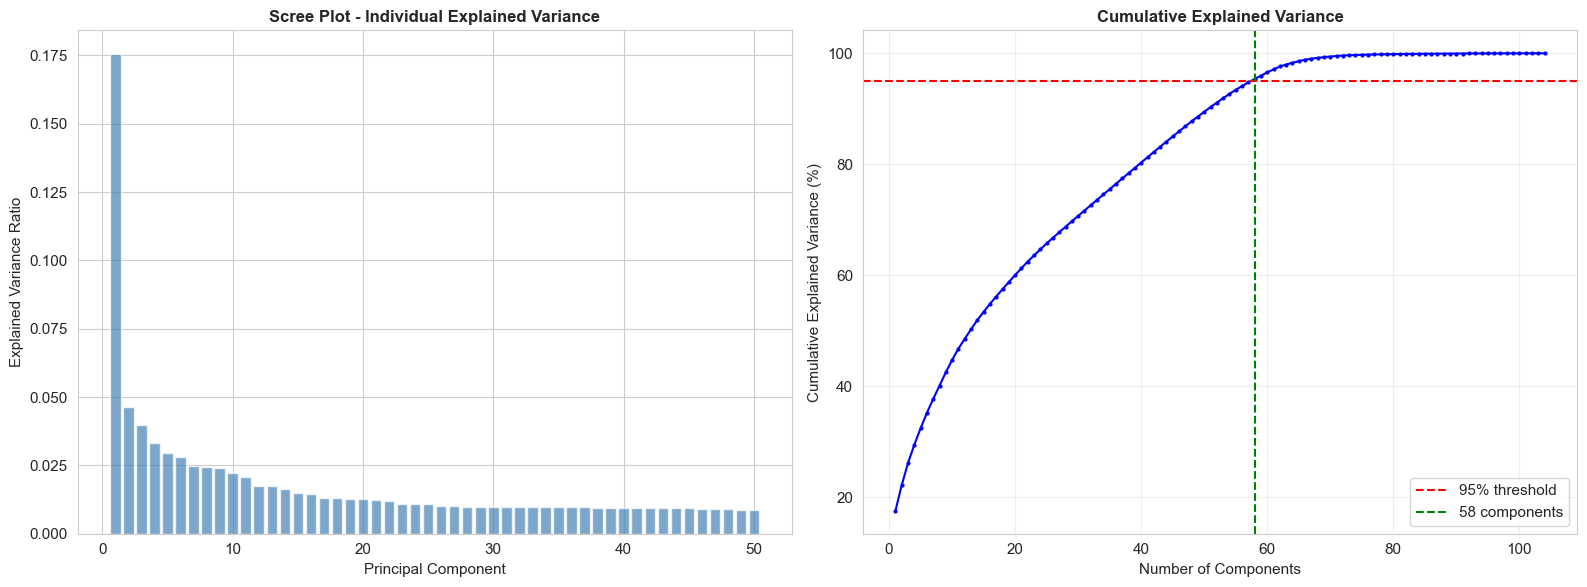

✓ Scree plot generated


In [7]:
# Scree Plot - Explained Variance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Individual explained variance (top 50 components)
n_show = min(50, len(pca_full.explained_variance_ratio_))
axes[0].bar(range(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show], alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot - Individual Explained Variance', fontsize=12, fontweight='bold')

# Cumulative explained variance
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, 'b-o', markersize=2)
axes[1].axhline(y=95, color='r', linestyle='--', label='95% threshold')
axes[1].axvline(x=n_components_95, color='g', linestyle='--', label=f'{n_components_95} components')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Scree plot generated")

In [8]:
# Apply PCA with 95% explained variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_numeric_scaled)

# Create DataFrame with PC columns
pca_columns = [f'PC_{i+1}' for i in range(X_pca.shape[1])]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns, index=X_numeric.index)

print(f"Original continuous features: {len(numeric_cols)}")
print(f"PCA components (95% variance): {X_pca.shape[1]}")
print(f"Dimensionality reduction: {len(numeric_cols)} → {X_pca.shape[1]} ({(1 - X_pca.shape[1]/len(numeric_cols))*100:.1f}% reduction)")
print(f"\nTotal explained variance: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Original continuous features: 104
PCA components (95% variance): 58
Dimensionality reduction: 104 → 58 (44.2% reduction)

Total explained variance: 95.37%


## Remove Highly Correlated Categorical Variables

In [9]:
# One-hot encode categorical features
X_cat_encoded = pd.get_dummies(X_categorical, drop_first=True)
print(f"Categorical features after one-hot encoding: {X_cat_encoded.shape[1]}")

# Sanitize feature names for LightGBM/XGBoost compatibility
X_cat_encoded.columns = [re.sub(r'[^a-zA-Z0-9_]', '_', str(col)) for col in X_cat_encoded.columns]
X_cat_encoded.columns = [re.sub(r'_+', '_', col).strip('_') for col in X_cat_encoded.columns]

# Handle duplicate column names after sanitization
cols = list(X_cat_encoded.columns)
seen = {}
for i, col in enumerate(cols):
    if col in seen:
        seen[col] += 1
        cols[i] = f"{col}_{seen[col]}"
    else:
        seen[col] = 0
X_cat_encoded.columns = cols

print(f"✓ Feature names sanitized")
print(f"Sample encoded columns: {X_cat_encoded.columns[:10].tolist()}")

Categorical features after one-hot encoding: 124
✓ Feature names sanitized
Sample encoded columns: ['NAME_CONTRACT_TYPE_Revolving_loans', 'CODE_GENDER_M', 'CODE_GENDER_XNA', 'FLAG_OWN_CAR_Y', 'FLAG_OWN_REALTY_Y', 'NAME_TYPE_SUITE_Family', 'NAME_TYPE_SUITE_Group_of_people', 'NAME_TYPE_SUITE_Other_A', 'NAME_TYPE_SUITE_Other_B', 'NAME_TYPE_SUITE_Spouse_partner']


In [10]:
# Compute correlation matrix for encoded categorical features
corr_matrix = X_cat_encoded.corr().abs()

# Get upper triangle to avoid duplicate pairs
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find highly correlated pairs (threshold = 0.8)
corr_threshold = 0.8
high_corr_pairs = []
for col in upper_tri.columns:
    correlated = upper_tri.index[upper_tri[col] >= corr_threshold].tolist()
    for corr_col in correlated:
        high_corr_pairs.append((corr_col, col, corr_matrix.loc[corr_col, col]))

print(f"Highly correlated pairs (|r| >= {corr_threshold}):")
if high_corr_pairs:
    for feat1, feat2, corr_val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
        print(f"  {feat1} ↔ {feat2}: {corr_val:.4f}")
else:
    print("  No highly correlated pairs found.")

print(f"\nTotal highly correlated pairs: {len(high_corr_pairs)}")

Highly correlated pairs (|r| >= 0.8):
  NAME_INCOME_TYPE_Pensioner ↔ ORGANIZATION_TYPE_XNA: 0.9996
  NAME_EDUCATION_TYPE_Higher_education ↔ NAME_EDUCATION_TYPE_Secondary_secondary_special: 0.8880
  WALLSMATERIAL_MODE_Panel ↔ WALLSMATERIAL_MODE_Stone_brick: 0.8352
  NAME_TYPE_SUITE_Family ↔ NAME_TYPE_SUITE_Unaccompanied: 0.8064

Total highly correlated pairs: 4


In [11]:
# Remove one feature from each highly correlated pair
cols_to_drop = set()
for col in upper_tri.columns:
    correlated = upper_tri.index[upper_tri[col] >= corr_threshold].tolist()
    cols_to_drop.update(correlated)

print(f"Features before correlation filtering: {X_cat_encoded.shape[1]}")
print(f"Features to remove: {len(cols_to_drop)}")
if cols_to_drop:
    print(f"Removed features: {sorted(cols_to_drop)}")

X_cat_filtered = X_cat_encoded.drop(columns=list(cols_to_drop))
print(f"Features after correlation filtering: {X_cat_filtered.shape[1]}")

Features before correlation filtering: 124
Features to remove: 4
Removed features: ['NAME_EDUCATION_TYPE_Higher_education', 'NAME_INCOME_TYPE_Pensioner', 'NAME_TYPE_SUITE_Family', 'WALLSMATERIAL_MODE_Panel']
Features after correlation filtering: 120


In [12]:
# Visualize correlation matrix of remaining categorical features (if manageable size)
if X_cat_filtered.shape[1] <= 50:
    fig, ax = plt.subplots(figsize=(16, 14))
    corr_filtered = X_cat_filtered.corr().abs()
    sns.heatmap(corr_filtered, cmap='coolwarm', center=0, ax=ax, 
                xticklabels=True, yticklabels=True, fmt='.1f',
                cbar_kws={'label': '|Correlation|'})
    ax.set_title(f'Correlation Matrix - Filtered Categorical Features ({X_cat_filtered.shape[1]} features)',
                fontsize=14, fontweight='bold')
    plt.xticks(rotation=90, fontsize=7)
    plt.yticks(fontsize=7)
    plt.tight_layout()
    plt.show()
else:
    print(f"Too many features ({X_cat_filtered.shape[1]}) for heatmap visualization")

print(f"✓ Correlation analysis complete")

Too many features (120) for heatmap visualization
✓ Correlation analysis complete


## Combine PCA Components + Filtered Categoricals

In [13]:
# Combine PCA-transformed continuous features with filtered categorical features
X_combined = pd.concat([X_pca_df, X_cat_filtered], axis=1)

print(f"PCA components: {X_pca_df.shape[1]}")
print(f"Filtered categorical features: {X_cat_filtered.shape[1]}")
print(f"Combined feature matrix: {X_combined.shape[1]} features")
print(f"\nSample columns: {X_combined.columns[:15].tolist()}")

PCA components: 58
Filtered categorical features: 120
Combined feature matrix: 178 features

Sample columns: ['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_8', 'PC_9', 'PC_10', 'PC_11', 'PC_12', 'PC_13', 'PC_14', 'PC_15']


In [14]:
# Scale the combined features (PCA components are already centered but categoricals may need scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)
X_scaled = pd.DataFrame(X_scaled, columns=X_combined.columns, index=X_combined.index)

print("✓ Combined features scaled using StandardScaler")
print(f"\nScaled features shape: {X_scaled.shape}")

✓ Combined features scaled using StandardScaler

Scaled features shape: (307511, 178)


In [15]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]:,} ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]:,} ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"\nTraining set features: {X_train.shape[1]}")
print(f"Testing set features: {X_test.shape[1]}")
print(f"\nTraining set TARGET distribution:")
print(y_train.value_counts())
print(f"\nTesting set TARGET distribution:")
print(y_test.value_counts())

Training set size: 246,008 (80.0%)
Testing set size: 61,503 (20.0%)

Training set features: 178
Testing set features: 178

Training set TARGET distribution:
TARGET
0    226148
1     19860
Name: count, dtype: int64

Testing set TARGET distribution:
TARGET
0    56538
1     4965
Name: count, dtype: int64


# Logistic Regression

In [16]:
# Initialize and train logistic regression model
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)
log_reg.fit(X_train, y_train)

print("✓ Logistic Regression model trained successfully")
print(f"\nModel parameters:")
print(f"  - Classes: {log_reg.classes_}")
print(f"  - Number of features: {log_reg.n_features_in_}")
print(f"  - Intercept: {log_reg.intercept_[0]:.6f}")

✓ Logistic Regression model trained successfully

Model parameters:
  - Classes: [0 1]
  - Number of features: 178
  - Intercept: -0.348655


In [17]:
# Make predictions
y_train_pred = log_reg.predict(X_train)
y_test_pred = log_reg.predict(X_test)
y_train_pred_proba = log_reg.predict_proba(X_train)[:, 1]
y_test_pred_proba = log_reg.predict_proba(X_test)[:, 1]

print("✓ Predictions generated for both training and testing sets")
print(f"\nTraining predictions distribution:")
print(pd.Series(y_train_pred).value_counts())
print(f"\nTesting predictions distribution:")
print(pd.Series(y_test_pred).value_counts())

✓ Predictions generated for both training and testing sets

Training predictions distribution:
0    161847
1     84161
Name: count, dtype: int64

Testing predictions distribution:
0    40629
1    20874
Name: count, dtype: int64


In [18]:
# Evaluate model performance on test set
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
roc_auc_test = roc_auc_score(y_test, y_test_pred_proba)

print("=" * 70)
print("LOGISTIC REGRESSION - PERFORMANCE METRICS (TEST SET)")
print("=" * 70)
print(f"Accuracy:   {accuracy_test:.4f}")
print(f"Precision:  {precision_test:.4f}")
print(f"Recall:     {recall_test:.4f}")
print(f"F1-Score:   {f1_test:.4f}")
print(f"ROC-AUC:    {roc_auc_test:.4f}")
print("=" * 70)

cm_test = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix:")
print(cm_test)
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Repay (0)', 'Default (1)']))

LOGISTIC REGRESSION - PERFORMANCE METRICS (TEST SET)
Accuracy:   0.6892
Precision:  0.1611
Recall:     0.6773
F1-Score:   0.2603
ROC-AUC:    0.7445

Confusion Matrix:
[[39027 17511]
 [ 1602  3363]]

Detailed Classification Report:
              precision    recall  f1-score   support

   Repay (0)       0.96      0.69      0.80     56538
 Default (1)       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



In [19]:
# Compare training vs test performance
print("\n" + "=" * 70)
print("TRAINING vs TEST SET COMPARISON")
print("=" * 70)

metrics_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Training Set': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),
        roc_auc_score(y_train, y_train_pred_proba)
    ],
    'Testing Set': [accuracy_test, precision_test, recall_test, f1_test, roc_auc_test]
})

metrics_comparison['Difference'] = metrics_comparison['Training Set'] - metrics_comparison['Testing Set']
print(metrics_comparison.to_string(index=False))


TRAINING vs TEST SET COMPARISON
   Metric  Training Set  Testing Set  Difference
 Accuracy      0.685860     0.689235   -0.003375
Precision      0.158862     0.161110   -0.002247
   Recall      0.673212     0.677341   -0.004129
 F1-Score      0.257063     0.260304   -0.003241
  ROC-AUC      0.744149     0.744481   -0.000332


## Feature Importance Analysis for LR

In [20]:
# Extract feature coefficients from logistic regression
feature_importance = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Coefficient': log_reg.coef_[0]
})

feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print("Top 20 Most Important Features (by Coefficient Magnitude):")
print(feature_importance.head(20).to_string(index=False))

Top 20 Most Important Features (by Coefficient Magnitude):
                                        Feature  Coefficient  Abs_Coefficient
                                          PC_23    -0.352509         0.352509
                                           PC_4     0.246122         0.246122
                                          PC_24    -0.232240         0.232240
                                           PC_3     0.229892         0.229892
                                          PC_13    -0.207168         0.207168
                                  CODE_GENDER_M     0.168288         0.168288
                                          PC_17    -0.163556         0.163556
                                          PC_55    -0.155450         0.155450
                                          PC_56    -0.155162         0.155162
                                 FLAG_OWN_CAR_Y    -0.138833         0.138833
NAME_EDUCATION_TYPE_Secondary_secondary_special     0.137679         0.137679
     

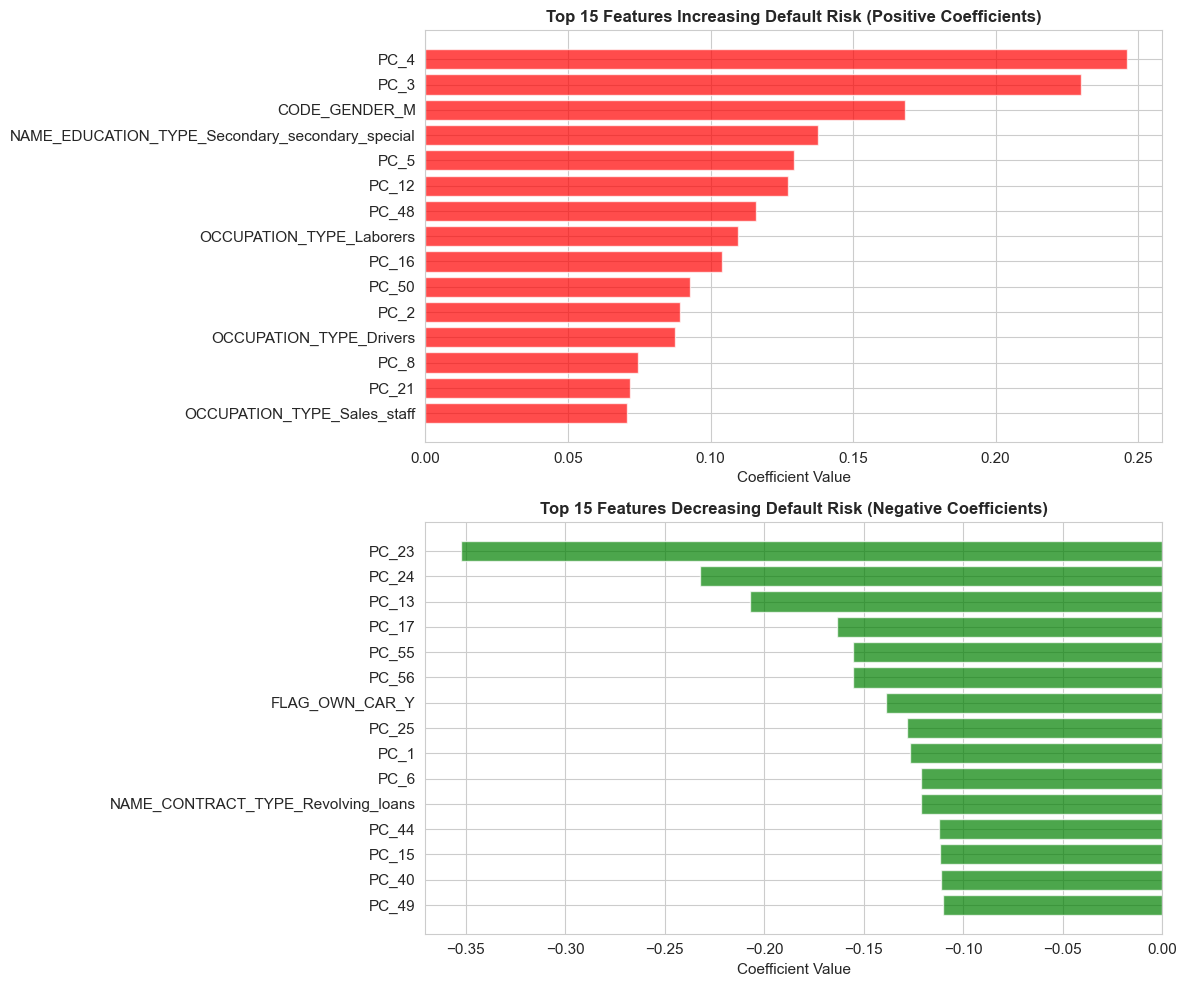

In [21]:
# Visualize top features
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

top_positive = feature_importance[feature_importance['Coefficient'] > 0].head(15)
axes[0].barh(range(len(top_positive)), top_positive['Coefficient'].values, color='red', alpha=0.7)
axes[0].set_yticks(range(len(top_positive)))
axes[0].set_yticklabels(top_positive['Feature'].values)
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title('Top 15 Features Increasing Default Risk (Positive Coefficients)',
                  fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

top_negative = feature_importance[feature_importance['Coefficient'] < 0].head(15)
axes[1].barh(range(len(top_negative)), top_negative['Coefficient'].values, color='green', alpha=0.7)
axes[1].set_yticks(range(len(top_negative)))
axes[1].set_yticklabels(top_negative['Feature'].values)
axes[1].set_xlabel('Coefficient Value')
axes[1].set_title('Top 15 Features Decreasing Default Risk (Negative Coefficients)',
                  fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

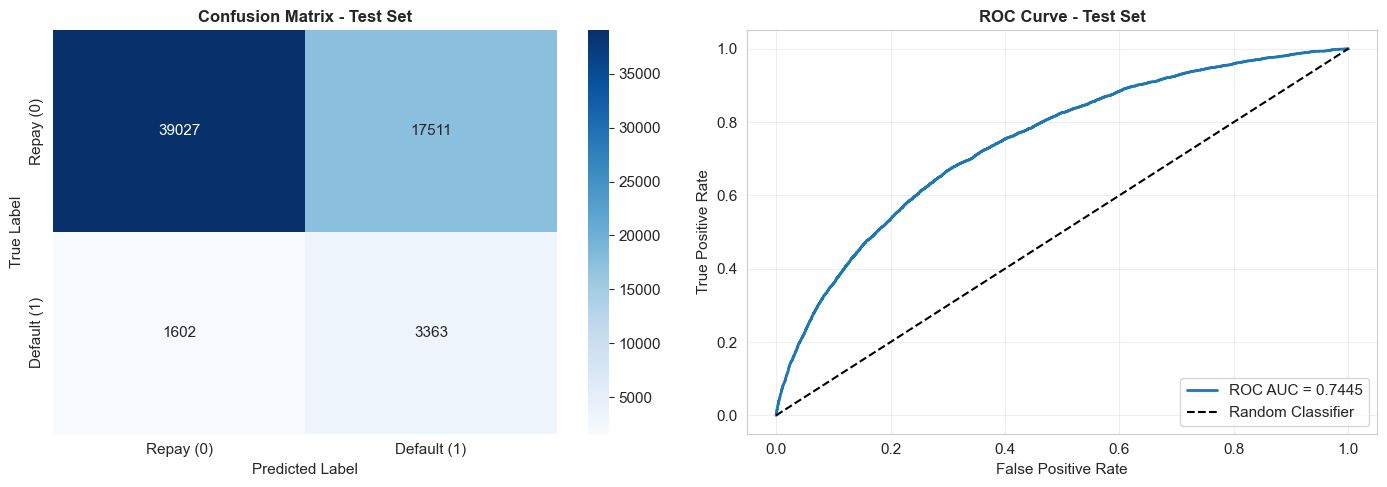

In [22]:
# Visualize Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Repay (0)', 'Default (1)'],
            yticklabels=['Repay (0)', 'Default (1)'])
axes[0].set_title('Confusion Matrix - Test Set', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)
axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc_test:.4f}', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Test Set', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## SHAP Values for LR

In [23]:
# SHAP for Logistic Regression
sample_size = min(5000, X_train.shape[0])
X_train_sample = X_train.sample(n=sample_size, random_state=42)

print(f"Creating SHAP LinearExplainer with {sample_size} background samples...")
explainer = shap.LinearExplainer(log_reg, X_train_sample)
print("✓ SHAP explainer created successfully")

Creating SHAP LinearExplainer with 5000 background samples...
✓ SHAP explainer created successfully


In [24]:
print("Calculating SHAP values for test set...")
shap_values_test = explainer.shap_values(X_test)
print(f"✓ SHAP values calculated - shape: {shap_values_test.shape}")

Calculating SHAP values for test set...
✓ SHAP values calculated - shape: (61503, 178)


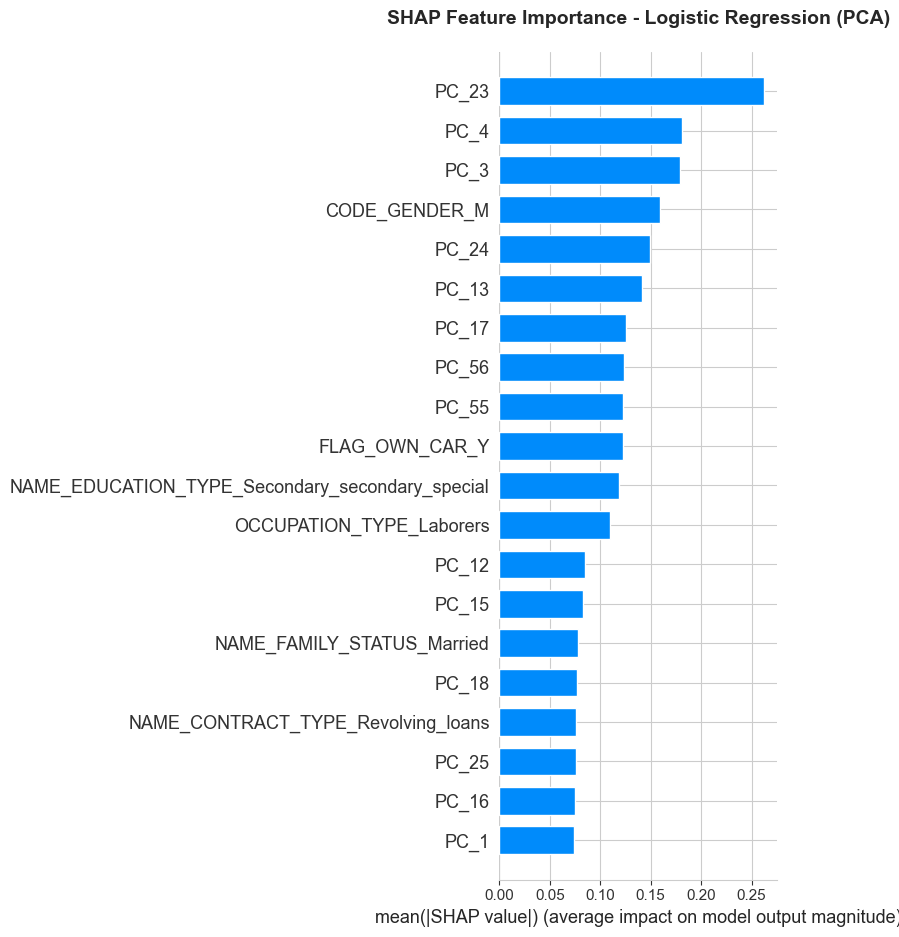

In [25]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_test, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Logistic Regression (PCA)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

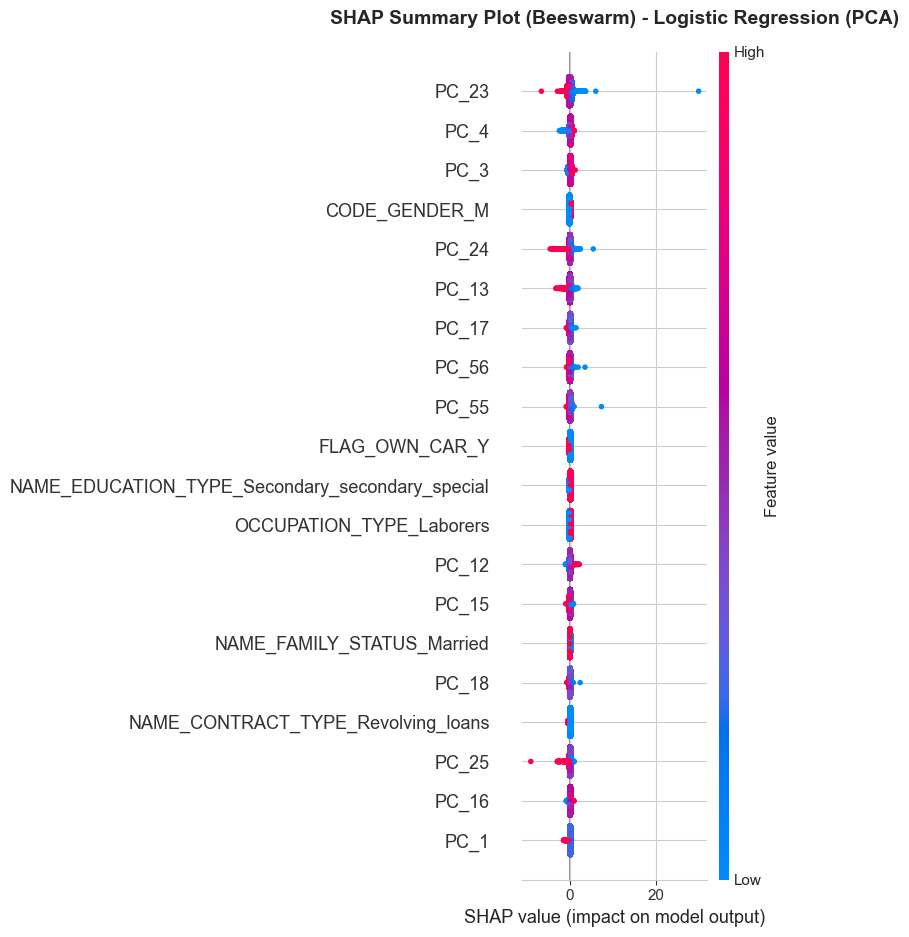

In [26]:
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_test, X_test, show=False)
plt.title('SHAP Summary Plot (Beeswarm) - Logistic Regression (PCA)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [27]:
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP': np.abs(shap_values_test).mean(axis=0)
})
shap_importance = shap_importance.sort_values('Mean_Abs_SHAP', ascending=False)

print("Top 15 Most Important Features (by Mean Absolute SHAP values):")
print(shap_importance.head(15).to_string(index=False))

Top 15 Most Important Features (by Mean Absolute SHAP values):
                                        Feature  Mean_Abs_SHAP
                                          PC_23       0.262137
                                           PC_4       0.180615
                                           PC_3       0.178817
                                  CODE_GENDER_M       0.159307
                                          PC_24       0.149430
                                          PC_13       0.141757
                                          PC_17       0.125622
                                          PC_56       0.123139
                                          PC_55       0.122870
                                 FLAG_OWN_CAR_Y       0.122346
NAME_EDUCATION_TYPE_Secondary_secondary_special       0.118711
                       OCCUPATION_TYPE_Laborers       0.109553
                                          PC_12       0.084889
                                          PC_15       0

# Random Forest

In [28]:
print("Training Random Forest model (this may take a few minutes)...")
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(X_train, y_train)

elapsed_time = time.time() - start_time
print(f"\n✓ Random Forest model trained successfully in {elapsed_time:.2f} seconds")
print(f"\nModel parameters:")
print(f"  - Number of trees: {rf_model.n_estimators}")
print(f"  - Max depth: {rf_model.max_depth}")
print(f"  - Number of features: {rf_model.n_features_in_}")
print(f"  - Classes: {rf_model.classes_}")

Training Random Forest model (this may take a few minutes)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    7.8s



✓ Random Forest model trained successfully in 20.42 seconds

Model parameters:
  - Number of trees: 100
  - Max depth: 5
  - Number of features: 178
  - Classes: [0 1]


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   20.1s finished


In [29]:
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)
y_train_pred_proba = rf_model.predict_proba(X_train)[:, 1]
y_test_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("✓ Predictions generated")
print(f"\nTraining predictions distribution:")
print(pd.Series(y_train_pred).value_counts())
print(f"\nTesting predictions distribution:")
print(pd.Series(y_test_pred).value_counts())

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.4s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s


✓ Predictions generated

Training predictions distribution:
0    162978
1     83030
Name: count, dtype: int64

Testing predictions distribution:
0    40914
1    20589
Name: count, dtype: int64


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.4s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


In [30]:
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
roc_auc_test = roc_auc_score(y_test, y_test_pred_proba)

print("=" * 70)
print("RANDOM FOREST - PERFORMANCE METRICS (TEST SET)")
print("=" * 70)
print(f"Accuracy:   {accuracy_test:.4f}")
print(f"Precision:  {precision_test:.4f}")
print(f"Recall:     {recall_test:.4f}")
print(f"F1-Score:   {f1_test:.4f}")
print(f"ROC-AUC:    {roc_auc_test:.4f}")
print("=" * 70)

cm_test = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix:")
print(cm_test)
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Repay (0)', 'Default (1)']))

RANDOM FOREST - PERFORMANCE METRICS (TEST SET)
Accuracy:   0.6839
Precision:  0.1484
Recall:     0.6153
F1-Score:   0.2391
ROC-AUC:    0.7097

Confusion Matrix:
[[39004 17534]
 [ 1910  3055]]

Detailed Classification Report:
              precision    recall  f1-score   support

   Repay (0)       0.95      0.69      0.80     56538
 Default (1)       0.15      0.62      0.24      4965

    accuracy                           0.68     61503
   macro avg       0.55      0.65      0.52     61503
weighted avg       0.89      0.68      0.76     61503



In [31]:
print("\n" + "=" * 70)
print("TRAINING vs TEST SET COMPARISON")
print("=" * 70)

metrics_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Training Set': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),
        roc_auc_score(y_train, y_train_pred_proba)
    ],
    'Testing Set': [accuracy_test, precision_test, recall_test, f1_test, roc_auc_test]
})

metrics_comparison['Difference'] = metrics_comparison['Training Set'] - metrics_comparison['Testing Set']
print(metrics_comparison.to_string(index=False))


TRAINING vs TEST SET COMPARISON
   Metric  Training Set  Testing Set  Difference
 Accuracy      0.684913     0.683853    0.001060
Precision      0.152812     0.148380    0.004432
   Recall      0.638872     0.615307    0.023565
 F1-Score      0.246632     0.239102    0.007531
  ROC-AUC      0.722593     0.709740    0.012852


## Feature Importance for RF

In [32]:
feature_importance = pd.DataFrame({
    'Feature': X_combined.columns,
    'Importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

print("Top 20 Most Important Features (by Mean Decrease in Impurity):")
print(feature_importance.head(20).to_string(index=False))

Top 20 Most Important Features (by Mean Decrease in Impurity):
                                        Feature  Importance
                                          PC_23    0.130915
                                           PC_3    0.074244
                                           PC_5    0.070975
                                           PC_1    0.061019
                                          PC_24    0.060408
                                           PC_4    0.054433
                                          PC_33    0.049180
                                           PC_6    0.045230
                                          PC_13    0.040366
                                          PC_38    0.037257
                                          PC_17    0.029906
                                          PC_26    0.027632
                                          PC_56    0.022134
                       NAME_INCOME_TYPE_Working    0.021727
                                     

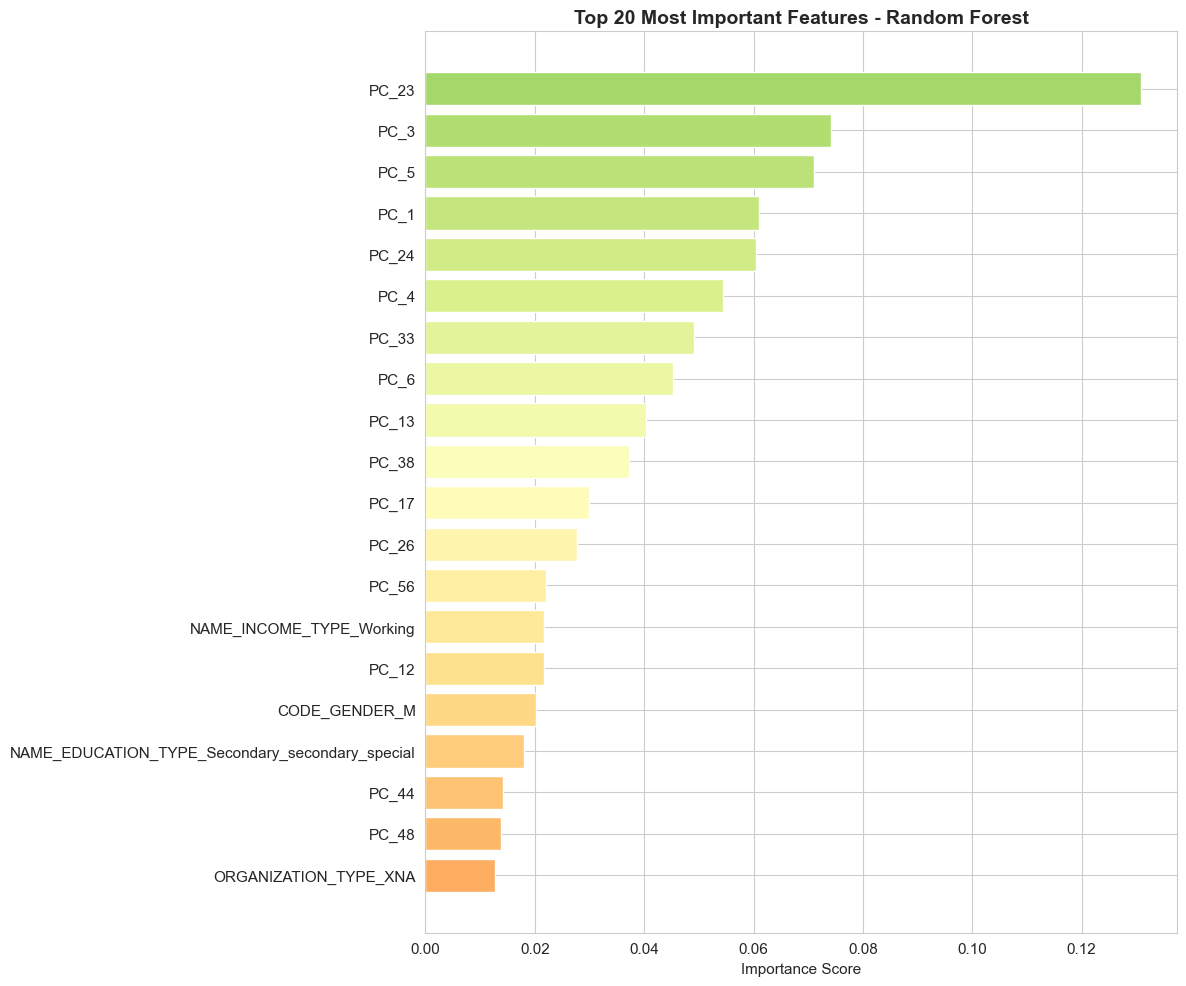

In [33]:
fig, ax = plt.subplots(figsize=(12, 10))

top_20_features = feature_importance.head(20)
colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.7, len(top_20_features)))

ax.barh(range(len(top_20_features)), top_20_features['Importance'].values, color=colors)
ax.set_yticks(range(len(top_20_features)))
ax.set_yticklabels(top_20_features['Feature'].values)
ax.set_xlabel('Importance Score')
ax.set_title('Top 20 Most Important Features - Random Forest', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

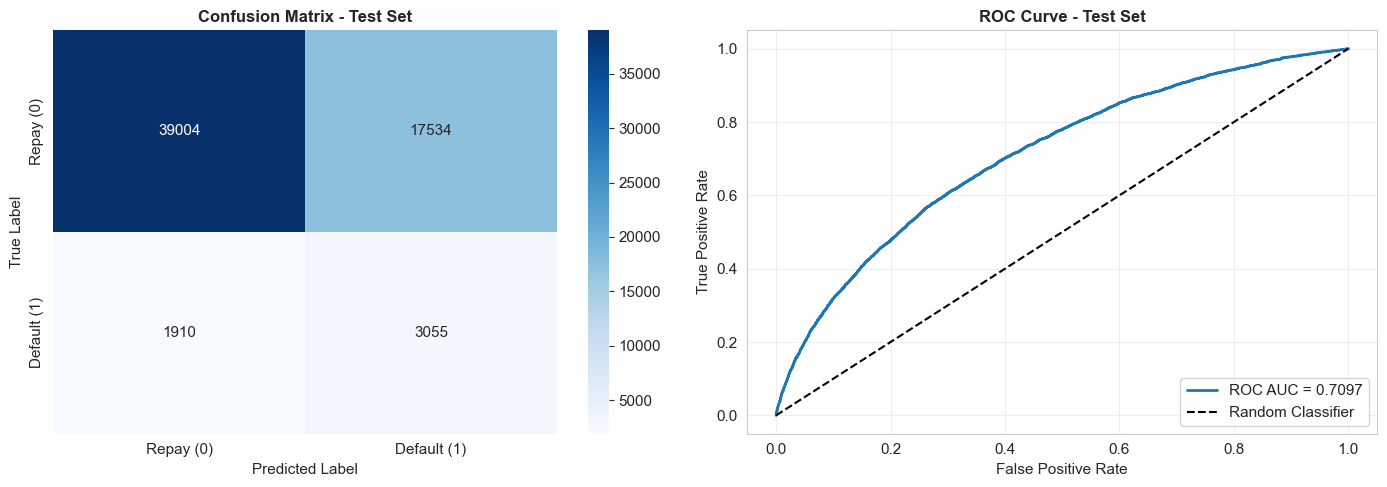

In [34]:
# Visualize Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Repay (0)', 'Default (1)'],
            yticklabels=['Repay (0)', 'Default (1)'])
axes[0].set_title('Confusion Matrix - Test Set', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)
axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc_test:.4f}', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Test Set', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## SHAP For RF

In [35]:
print("Creating SHAP TreeExplainer for Random Forest...")
explainer = shap.TreeExplainer(rf_model)
print("✓ SHAP explainer created successfully")

Creating SHAP TreeExplainer for Random Forest...
✓ SHAP explainer created successfully


In [36]:
print("Calculating SHAP values for test set...")
shap_values_test = explainer.shap_values(X_test)
print(f"✓ SHAP values calculated - shape: {shap_values_test.shape}")

# Handle 3D SHAP values (n_samples, n_features, n_classes)
if len(shap_values_test.shape) == 3:
    shap_values_test_reshaped = shap_values_test[:, :, 1]  # Class 1 (default)
    print(f"Reshaped to: {shap_values_test_reshaped.shape}")
else:
    shap_values_test_reshaped = shap_values_test

Calculating SHAP values for test set...
✓ SHAP values calculated - shape: (61503, 178, 2)
Reshaped to: (61503, 178)


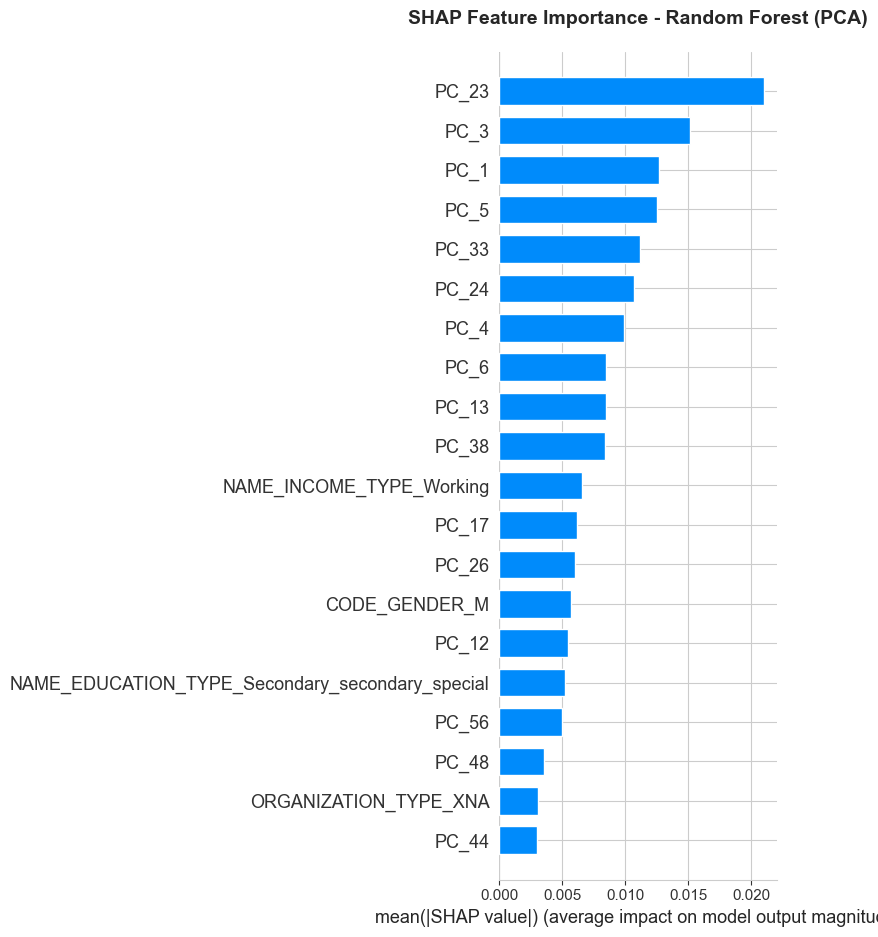

In [37]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_test_reshaped, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Random Forest (PCA)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

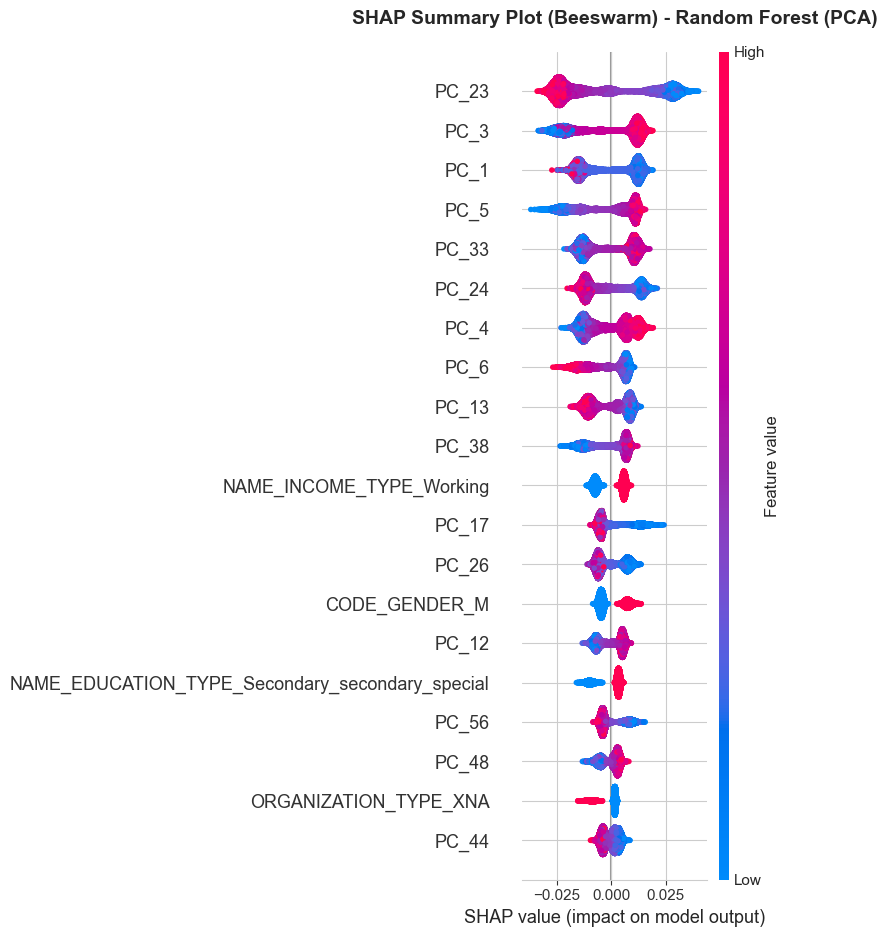

In [38]:
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_test_reshaped, X_test, show=False)
plt.title('SHAP Summary Plot (Beeswarm) - Random Forest (PCA)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [39]:
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP': np.abs(shap_values_test_reshaped).mean(axis=0)
})
shap_importance = shap_importance.sort_values('Mean_Abs_SHAP', ascending=False)

print("Top 15 Most Important Features (by Mean Absolute SHAP values):")
print(shap_importance.head(15).to_string(index=False))

Top 15 Most Important Features (by Mean Absolute SHAP values):
                 Feature  Mean_Abs_SHAP
                   PC_23       0.020988
                    PC_3       0.015093
                    PC_1       0.012683
                    PC_5       0.012507
                   PC_33       0.011182
                   PC_24       0.010670
                    PC_4       0.009856
                    PC_6       0.008475
                   PC_13       0.008439
                   PC_38       0.008378
NAME_INCOME_TYPE_Working       0.006576
                   PC_17       0.006145
                   PC_26       0.005988
           CODE_GENDER_M       0.005708
                   PC_12       0.005468


# LightGBM Model

In [40]:
print("Training LightGBM model (this may take a few minutes)...")
start_time = time.time()

lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    num_leaves=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(X_train, y_train)

elapsed_time = time.time() - start_time
print(f"\n✓ LightGBM model trained successfully in {elapsed_time:.2f} seconds")
print(f"\nModel parameters:")
print(f"  - Number of trees: {lgb_model.n_estimators}")
print(f"  - Max depth: {lgb_model.max_depth}")
print(f"  - Learning rate: {lgb_model.learning_rate}")
print(f"  - Number of leaves: {lgb_model.num_leaves}")
print(f"  - Number of features: {lgb_model.n_features_in_}")
print(f"  - Classes: {lgb_model.classes_}")

Training LightGBM model (this may take a few minutes)...

✓ LightGBM model trained successfully in 6.17 seconds

Model parameters:
  - Number of trees: 100
  - Max depth: 8
  - Learning rate: 0.1
  - Number of leaves: 20
  - Number of features: 178
  - Classes: [0 1]


In [41]:
y_train_pred = lgb_model.predict(X_train)
y_test_pred = lgb_model.predict(X_test)
y_train_pred_proba = lgb_model.predict_proba(X_train)[:, 1]
y_test_pred_proba = lgb_model.predict_proba(X_test)[:, 1]

print("✓ Predictions generated")
print(f"\nTraining predictions distribution:")
print(pd.Series(y_train_pred).value_counts())
print(f"\nTesting predictions distribution:")
print(pd.Series(y_test_pred).value_counts())

✓ Predictions generated

Training predictions distribution:
0    164101
1     81907
Name: count, dtype: int64

Testing predictions distribution:
0    41270
1    20233
Name: count, dtype: int64


In [42]:
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
roc_auc_test = roc_auc_score(y_test, y_test_pred_proba)

print("=" * 70)
print("LIGHTGBM - PERFORMANCE METRICS (TEST SET)")
print("=" * 70)
print(f"Accuracy:   {accuracy_test:.4f}")
print(f"Precision:  {precision_test:.4f}")
print(f"Recall:     {recall_test:.4f}")
print(f"F1-Score:   {f1_test:.4f}")
print(f"ROC-AUC:    {roc_auc_test:.4f}")
print("=" * 70)

cm_test = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix:")
print(cm_test)
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Repay (0)', 'Default (1)']))

LIGHTGBM - PERFORMANCE METRICS (TEST SET)
Accuracy:   0.6956
Precision:  0.1601
Recall:     0.6524
F1-Score:   0.2571
ROC-AUC:    0.7385

Confusion Matrix:
[[39544 16994]
 [ 1726  3239]]

Detailed Classification Report:
              precision    recall  f1-score   support

   Repay (0)       0.96      0.70      0.81     56538
 Default (1)       0.16      0.65      0.26      4965

    accuracy                           0.70     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.89      0.70      0.76     61503



In [43]:
print("\n" + "=" * 70)
print("TRAINING vs TEST SET COMPARISON")
print("=" * 70)

metrics_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Training Set': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),
        roc_auc_score(y_train, y_train_pred_proba)
    ],
    'Testing Set': [accuracy_test, precision_test, recall_test, f1_test, roc_auc_test]
})

metrics_comparison['Difference'] = metrics_comparison['Training Set'] - metrics_comparison['Testing Set']
print(metrics_comparison.to_string(index=False))


TRAINING vs TEST SET COMPARISON
   Metric  Training Set  Testing Set  Difference
 Accuracy      0.700022     0.695625    0.004397
Precision      0.170742     0.160085    0.010657
   Recall      0.704179     0.652367    0.051813
 F1-Score      0.274844     0.257084    0.017760
  ROC-AUC      0.773087     0.738485    0.034602


## Feature Importance for LightGBM

In [44]:
feature_importance = pd.DataFrame({
    'Feature': X_combined.columns,
    'Importance': lgb_model.feature_importances_
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

print("Top 20 Most Important Features (by Gain):")
print(feature_importance.head(20).to_string(index=False))

Top 20 Most Important Features (by Gain):
Feature  Importance
  PC_23          89
  PC_24          84
  PC_55          83
  PC_13          75
  PC_17          75
  PC_56          74
   PC_3          72
  PC_38          54
  PC_15          54
   PC_6          54
  PC_50          52
   PC_5          51
  PC_44          45
  PC_12          42
   PC_4          42
  PC_48          39
  PC_18          38
  PC_32          38
  PC_51          36
  PC_49          34


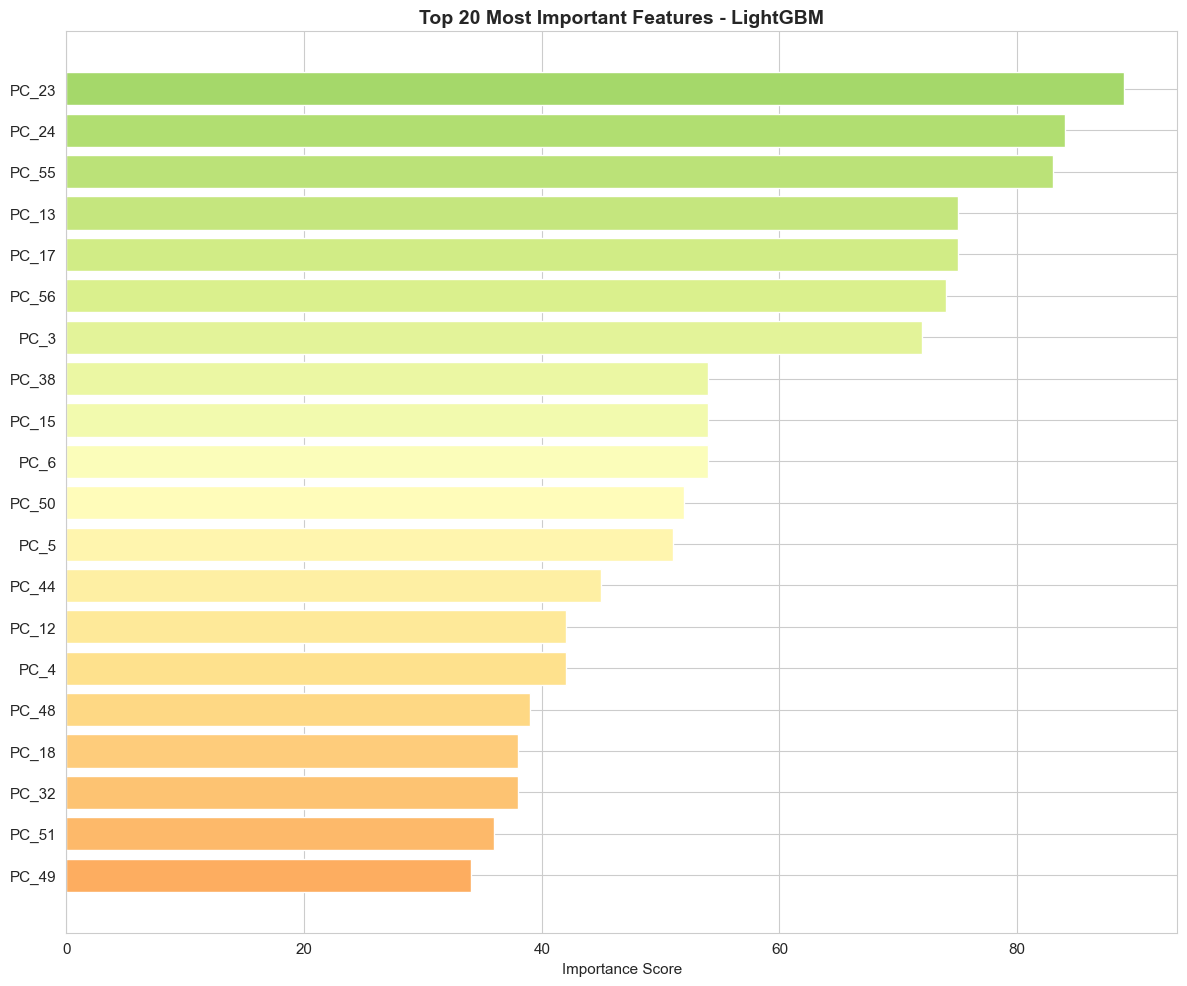

In [45]:
fig, ax = plt.subplots(figsize=(12, 10))

top_20_features = feature_importance.head(20)
colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.7, len(top_20_features)))

ax.barh(range(len(top_20_features)), top_20_features['Importance'].values, color=colors)
ax.set_yticks(range(len(top_20_features)))
ax.set_yticklabels(top_20_features['Feature'].values)
ax.set_xlabel('Importance Score')
ax.set_title('Top 20 Most Important Features - LightGBM', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

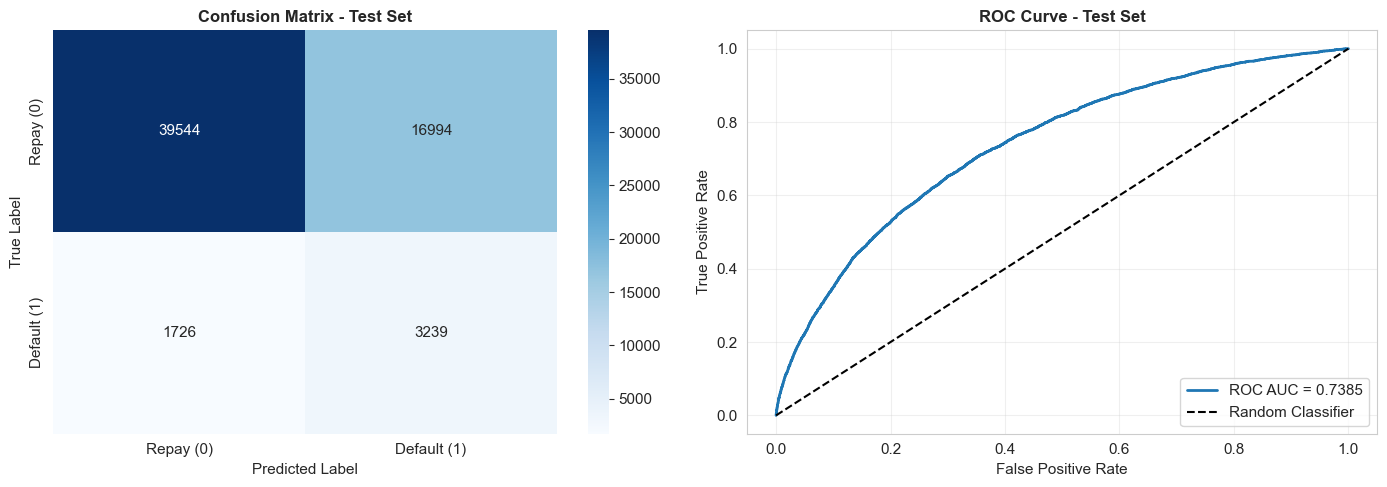

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Repay (0)', 'Default (1)'],
            yticklabels=['Repay (0)', 'Default (1)'])
axes[0].set_title('Confusion Matrix - Test Set', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)
axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc_test:.4f}', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Test Set', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## SHAP Values for LightGBM

In [47]:
print("Creating SHAP TreeExplainer for LightGBM...")
explainer = shap.TreeExplainer(lgb_model)
print("✓ SHAP explainer created successfully")

Creating SHAP TreeExplainer for LightGBM...
✓ SHAP explainer created successfully


In [48]:
print("Calculating SHAP values for test set...")
shap_values_test = explainer.shap_values(X_test)
print(f"✓ SHAP values calculated - shape: {np.array(shap_values_test).shape}")

# LightGBM SHAP may return a list [class0_shap, class1_shap] or 3D array
if isinstance(shap_values_test, list):
    shap_values_test = shap_values_test[1]  # Class 1 (default)
    print(f"Selected class 1 SHAP values - shape: {shap_values_test.shape}")
elif len(np.array(shap_values_test).shape) == 3:
    shap_values_test = shap_values_test[:, :, 1]
    print(f"Reshaped to: {shap_values_test.shape}")

Calculating SHAP values for test set...
✓ SHAP values calculated - shape: (61503, 178)


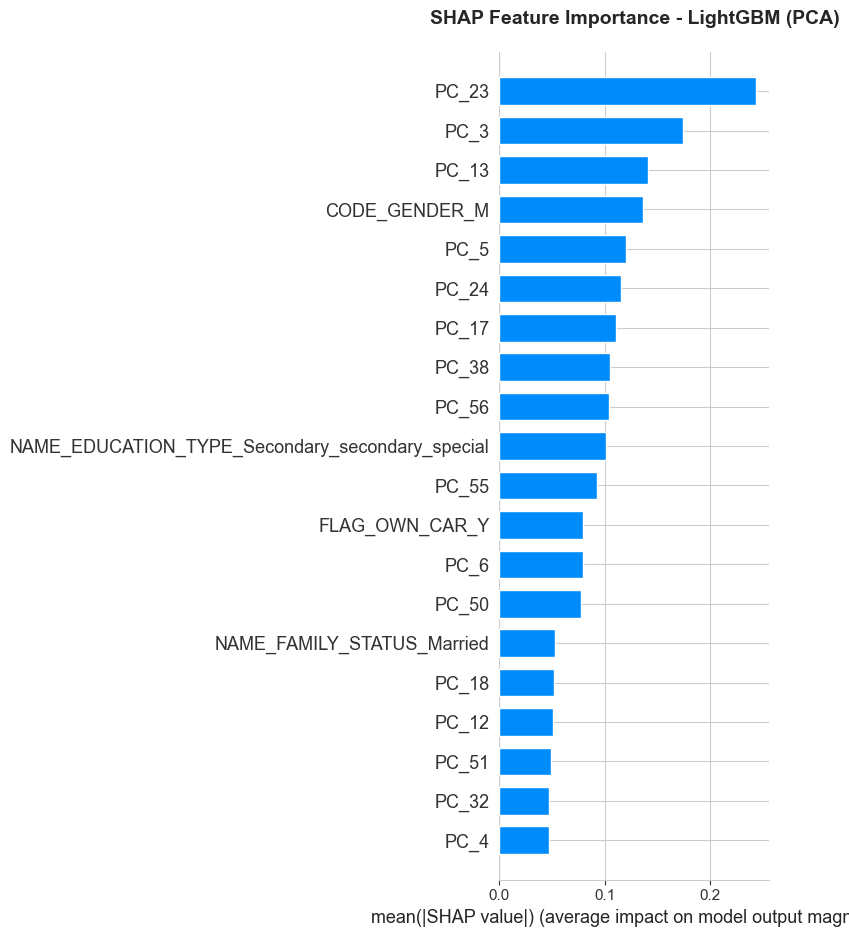

In [49]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_test, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - LightGBM (PCA)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

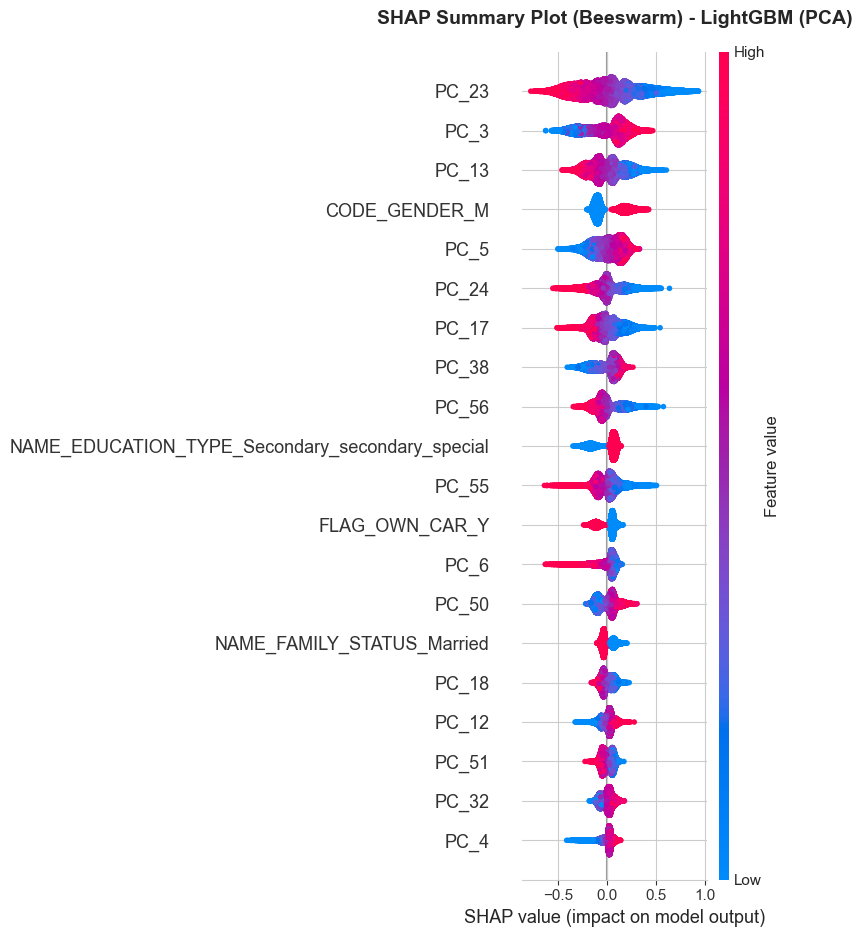

In [50]:
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_test, X_test, show=False)
plt.title('SHAP Summary Plot (Beeswarm) - LightGBM (PCA)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [51]:
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP': np.abs(shap_values_test).mean(axis=0)
})
shap_importance = shap_importance.sort_values('Mean_Abs_SHAP', ascending=False)

print("Top 15 Most Important Features (by Mean Absolute SHAP values):")
print(shap_importance.head(15).to_string(index=False))

Top 15 Most Important Features (by Mean Absolute SHAP values):
                                        Feature  Mean_Abs_SHAP
                                          PC_23       0.244348
                                           PC_3       0.174657
                                          PC_13       0.141433
                                  CODE_GENDER_M       0.136765
                                           PC_5       0.120614
                                          PC_24       0.115556
                                          PC_17       0.110871
                                          PC_38       0.105394
                                          PC_56       0.104058
NAME_EDUCATION_TYPE_Secondary_secondary_special       0.101677
                                          PC_55       0.092715
                                 FLAG_OWN_CAR_Y       0.079302
                                           PC_6       0.079252
                                          PC_50       0

# XGBoost Model

In [52]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

print("\nTraining XGBoost model (this may take a few minutes)...")
start_time = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=90,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train)

elapsed_time = time.time() - start_time
print(f"\n✓ XGBoost model trained successfully in {elapsed_time:.2f} seconds")
print(f"\nModel parameters:")
print(f"  - Number of trees: {xgb_model.n_estimators}")
print(f"  - Max depth: {xgb_model.max_depth}")
print(f"  - Learning rate: {xgb_model.learning_rate}")
print(f"  - scale_pos_weight: {scale_pos_weight:.2f}")
print(f"  - Number of features: {xgb_model.n_features_in_}")

scale_pos_weight: 11.39

Training XGBoost model (this may take a few minutes)...

✓ XGBoost model trained successfully in 6.72 seconds

Model parameters:
  - Number of trees: 90
  - Max depth: 5
  - Learning rate: 0.1
  - scale_pos_weight: 11.39
  - Number of features: 178


In [53]:
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)
y_train_pred_proba = xgb_model.predict_proba(X_train)[:, 1]
y_test_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("✓ Predictions generated")
print(f"\nTraining predictions distribution:")
print(pd.Series(y_train_pred).value_counts())
print(f"\nTesting predictions distribution:")
print(pd.Series(y_test_pred).value_counts())

✓ Predictions generated

Training predictions distribution:
0    165330
1     80678
Name: count, dtype: int64

Testing predictions distribution:
0    41613
1    19890
Name: count, dtype: int64


In [54]:
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
roc_auc_test = roc_auc_score(y_test, y_test_pred_proba)

print("=" * 70)
print("XGBOOST - PERFORMANCE METRICS (TEST SET)")
print("=" * 70)
print(f"Accuracy:   {accuracy_test:.4f}")
print(f"Precision:  {precision_test:.4f}")
print(f"Recall:     {recall_test:.4f}")
print(f"F1-Score:   {f1_test:.4f}")
print(f"ROC-AUC:    {roc_auc_test:.4f}")
print("=" * 70)

cm_test = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix:")
print(cm_test)
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Repay (0)', 'Default (1)']))

XGBOOST - PERFORMANCE METRICS (TEST SET)
Accuracy:   0.6998
Precision:  0.1607
Recall:     0.6439
F1-Score:   0.2573
ROC-AUC:    0.7368

Confusion Matrix:
[[39845 16693]
 [ 1768  3197]]

Detailed Classification Report:
              precision    recall  f1-score   support

   Repay (0)       0.96      0.70      0.81     56538
 Default (1)       0.16      0.64      0.26      4965

    accuracy                           0.70     61503
   macro avg       0.56      0.67      0.53     61503
weighted avg       0.89      0.70      0.77     61503



In [55]:
print("\n" + "=" * 70)
print("TRAINING vs TEST SET COMPARISON")
print("=" * 70)

metrics_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Training Set': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),
        roc_auc_score(y_train, y_train_pred_proba)
    ],
    'Testing Set': [accuracy_test, precision_test, recall_test, f1_test, roc_auc_test]
})

metrics_comparison['Difference'] = metrics_comparison['Training Set'] - metrics_comparison['Testing Set']
print(metrics_comparison.to_string(index=False))


TRAINING vs TEST SET COMPARISON
   Metric  Training Set  Testing Set  Difference
 Accuracy      0.706400     0.699836    0.006564
Precision      0.175451     0.160734    0.014717
   Recall      0.712739     0.643907    0.068832
 F1-Score      0.281585     0.257252    0.024333
  ROC-AUC      0.781657     0.736819    0.044839


## Feature Importance For XGBoost

In [56]:
feature_importance = pd.DataFrame({
    'Feature': X_combined.columns,
    'Importance': xgb_model.feature_importances_
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

print("Top 20 Most Important Features (by Gain):")
print(feature_importance.head(20).to_string(index=False))

Top 20 Most Important Features (by Gain):
                                        Feature  Importance
                                          PC_23    0.056636
                                           PC_3    0.034018
                                           PC_5    0.033373
                                  CODE_GENDER_M    0.031126
NAME_EDUCATION_TYPE_Secondary_secondary_special    0.029992
                       NAME_INCOME_TYPE_Working    0.027442
                                          PC_13    0.023422
                                          PC_38    0.023162
                                           PC_6    0.018899
                                          PC_24    0.017888
                                 FLAG_OWN_CAR_Y    0.017572
            NAME_EDUCATION_TYPE_Lower_secondary    0.017217
          NAME_INCOME_TYPE_Commercial_associate    0.017003
                     NAME_FAMILY_STATUS_Married    0.016337
                                           PC_1    0.01556

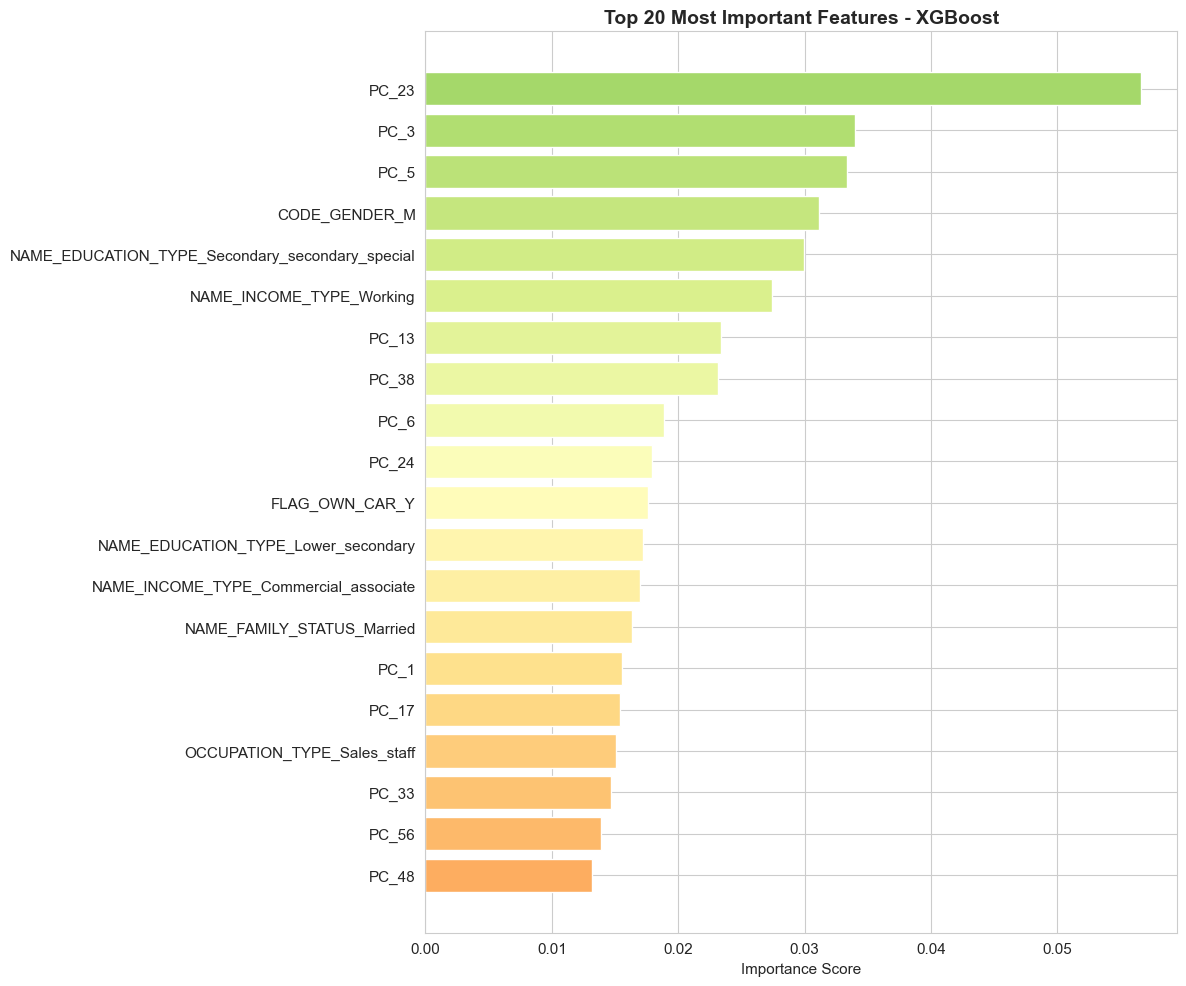

In [57]:
fig, ax = plt.subplots(figsize=(12, 10))

top_20_features = feature_importance.head(20)
colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.7, len(top_20_features)))

ax.barh(range(len(top_20_features)), top_20_features['Importance'].values, color=colors)
ax.set_yticks(range(len(top_20_features)))
ax.set_yticklabels(top_20_features['Feature'].values)
ax.set_xlabel('Importance Score')
ax.set_title('Top 20 Most Important Features - XGBoost', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

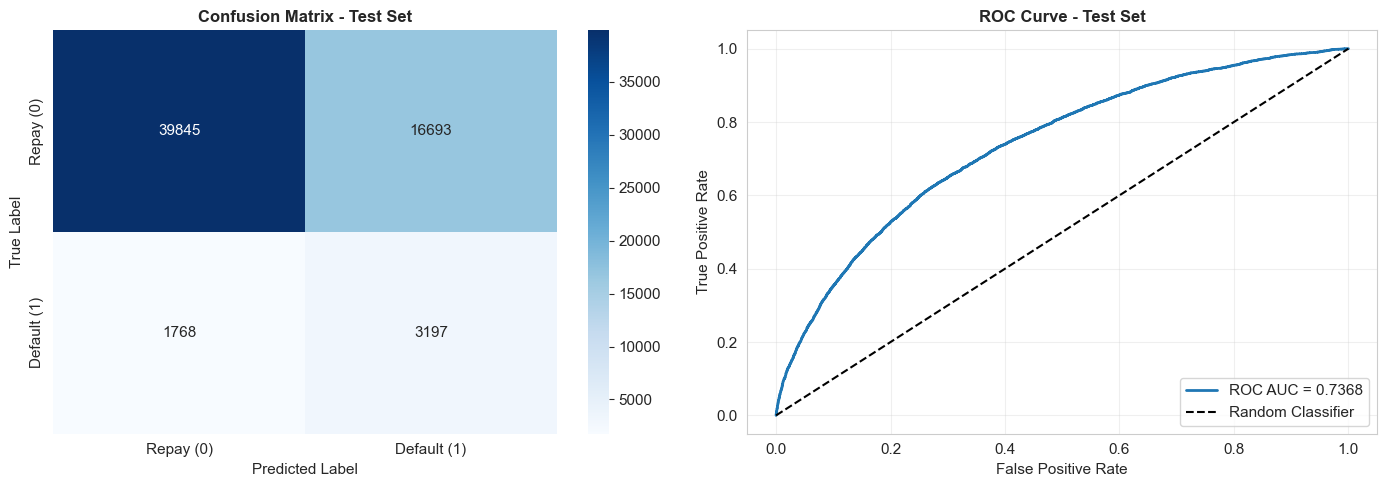

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Repay (0)', 'Default (1)'],
            yticklabels=['Repay (0)', 'Default (1)'])
axes[0].set_title('Confusion Matrix - Test Set', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)
axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc_test:.4f}', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Test Set', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## SHAP Values for XGBoost

In [59]:
print("Creating SHAP TreeExplainer for XGBoost...")
explainer = shap.TreeExplainer(xgb_model)
print("✓ SHAP explainer created successfully")

Creating SHAP TreeExplainer for XGBoost...
✓ SHAP explainer created successfully


In [60]:
print("Calculating SHAP values for test set...")
shap_values_test = explainer.shap_values(X_test)
print(f"✓ SHAP values calculated - shape: {shap_values_test.shape}")

# Handle 3D SHAP values if needed
if len(shap_values_test.shape) == 3:
    shap_values_test = shap_values_test[:, :, 1]
    print(f"Reshaped to: {shap_values_test.shape}")

Calculating SHAP values for test set...
✓ SHAP values calculated - shape: (61503, 178)


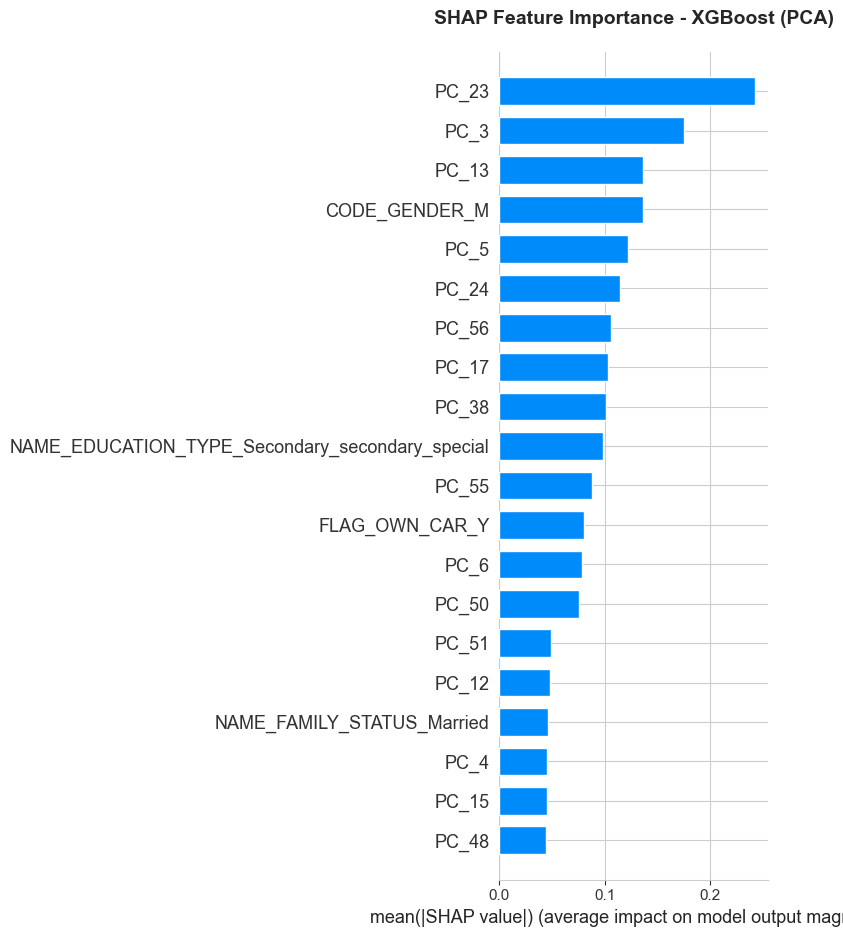

In [61]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_test, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - XGBoost (PCA)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

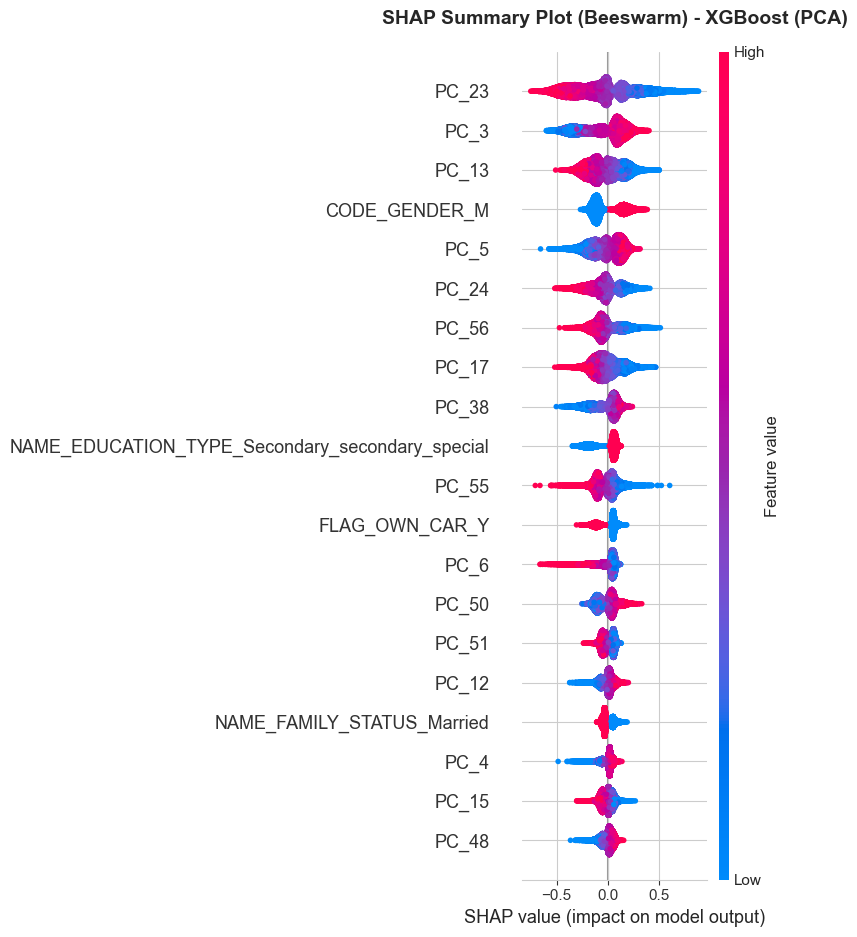

In [62]:
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_test, X_test, show=False)
plt.title('SHAP Summary Plot (Beeswarm) - XGBoost (PCA)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [63]:
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP': np.abs(shap_values_test).mean(axis=0)
})
shap_importance = shap_importance.sort_values('Mean_Abs_SHAP', ascending=False)

print("Top 15 Most Important Features (by Mean Absolute SHAP values):")
print(shap_importance.head(15).to_string(index=False))

Top 15 Most Important Features (by Mean Absolute SHAP values):
                                        Feature  Mean_Abs_SHAP
                                          PC_23       0.243004
                                           PC_3       0.175402
                                          PC_13       0.136792
                                  CODE_GENDER_M       0.136679
                                           PC_5       0.122622
                                          PC_24       0.114938
                                          PC_56       0.105923
                                          PC_17       0.103321
                                          PC_38       0.101119
NAME_EDUCATION_TYPE_Secondary_secondary_special       0.098696
                                          PC_55       0.088269
                                 FLAG_OWN_CAR_Y       0.080614
                                           PC_6       0.078929
                                          PC_50       0

# Fairness Analysis using Fairlearn

Evaluate model fairness across sensitive attributes (e.g., Gender) using Fairlearn metrics.

In [64]:
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference
from fairlearn.metrics import demographic_parity_ratio, equalized_odds_ratio

# Reload original data to get sensitive attributes
df_original = pd.read_csv("../dataset/application_train.csv", encoding="latin-1")

# Extract sensitive attribute for test set using indices
sensitive_feature = df_original.loc[X_test.index, 'CODE_GENDER'].values

print(f"Sensitive attribute: CODE_GENDER")
print(f"Distribution in test set:")
print(pd.Series(sensitive_feature).value_counts())
print(f"\nUnique values: {np.unique(sensitive_feature)}")

Sensitive attribute: CODE_GENDER
Distribution in test set:
F      40561
M      20940
XNA        2
Name: count, dtype: int64

Unique values: ['F' 'M' 'XNA']


In [65]:
# Generate predictions from all models for fairness comparison
models = {
    'Logistic Regression': log_reg,
    'Random Forest': rf_model,
    'LightGBM': lgb_model,
    'XGBoost': xgb_model
}

model_predictions = {}
for name, model in models.items():
    model_predictions[name] = {
        'y_pred': model.predict(X_test),
        'y_pred_proba': model.predict_proba(X_test)[:, 1]
    }

print("✓ Predictions generated for all models")
for name in models:
    pred_dist = pd.Series(model_predictions[name]['y_pred']).value_counts()
    print(f"\n{name} - Test predictions: 0={pred_dist.get(0, 0)}, 1={pred_dist.get(1, 0)}")

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


✓ Predictions generated for all models

Logistic Regression - Test predictions: 0=40629, 1=20874

Random Forest - Test predictions: 0=40914, 1=20589

LightGBM - Test predictions: 0=41270, 1=20233

XGBoost - Test predictions: 0=41613, 1=19890


In [66]:
# Fairness metrics for each model
print("=" * 80)
print("FAIRNESS ANALYSIS BY GENDER (CODE_GENDER)")
print("=" * 80)

fairness_results = []

for model_name in models:
    y_pred = model_predictions[model_name]['y_pred']
    y_proba = model_predictions[model_name]['y_pred_proba']
    
    mf = MetricFrame(
        metrics={
            'Accuracy': accuracy_score,
            'Precision': precision_score,
            'Recall': recall_score,
            'F1-Score': f1_score,
            'Selection Rate': lambda y_true, y_pred: np.mean(y_pred)
        },
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=sensitive_feature
    )
    
    print(f"\n{'─' * 80}")
    print(f"Model: {model_name}")
    print(f"{'─' * 80}")
    print(f"\nMetrics by group:")
    print(mf.by_group.to_string())
    print(f"\nDifference (max - min across groups):")
    print(mf.difference().to_string())
    
    dpd = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_feature)
    eod = equalized_odds_difference(y_test, y_pred, sensitive_features=sensitive_feature)
    dpr = demographic_parity_ratio(y_test, y_pred, sensitive_features=sensitive_feature)
    eor = equalized_odds_ratio(y_test, y_pred, sensitive_features=sensitive_feature)
    
    print(f"\nDemographic Parity Difference: {dpd:.4f}")
    print(f"Demographic Parity Ratio:      {dpr:.4f}")
    print(f"Equalized Odds Difference:     {eod:.4f}")
    print(f"Equalized Odds Ratio:          {eor:.4f}")
    
    fairness_results.append({
        'Model': model_name,
        'Demographic Parity Diff': dpd,
        'Demographic Parity Ratio': dpr,
        'Equalized Odds Diff': eod,
        'Equalized Odds Ratio': eor
    })

print(f"\n{'=' * 80}")
print("FAIRNESS COMPARISON ACROSS MODELS")
print(f"{'=' * 80}")
fairness_df = pd.DataFrame(fairness_results)
print(fairness_df.to_string(index=False))
print("\nNote: Values closer to 0 (difference) or 1 (ratio) indicate greater fairness.")

FAIRNESS ANALYSIS BY GENDER (CODE_GENDER)

────────────────────────────────────────────────────────────────────────────────
Model: Logistic Regression
────────────────────────────────────────────────────────────────────────────────

Metrics by group:
                     Accuracy  Precision    Recall  F1-Score  Selection Rate
sensitive_feature_0                                                         
F                    0.736249   0.151631  0.603315  0.242351        0.278198
M                    0.598138   0.172263  0.775951  0.281935        0.457975
XNA                  1.000000   0.000000  0.000000  0.000000        0.000000

Difference (max - min across groups):
Accuracy          0.401862
Precision         0.172263
Recall            0.775951
F1-Score          0.281935
Selection Rate    0.457975

Demographic Parity Difference: 0.4580
Demographic Parity Ratio:      0.0000
Equalized Odds Difference:     0.7760
Equalized Odds Ratio:          0.0000

────────────────────────────────────

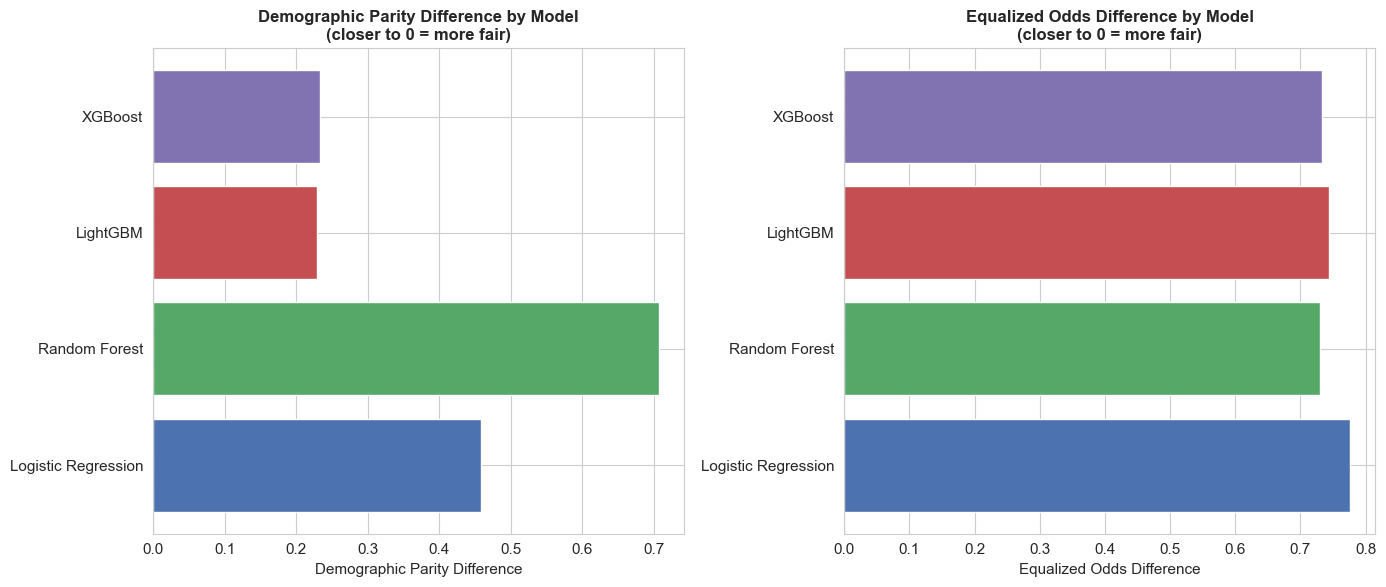

✓ Fairness comparison visualization generated


In [67]:
# Visualize fairness metrics across models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(fairness_df['Model'], fairness_df['Demographic Parity Diff'],
             color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
axes[0].set_xlabel('Demographic Parity Difference')
axes[0].set_title('Demographic Parity Difference by Model\n(closer to 0 = more fair)',
                  fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='--', alpha=0.5)

axes[1].barh(fairness_df['Model'], fairness_df['Equalized Odds Diff'],
             color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
axes[1].set_xlabel('Equalized Odds Difference')
axes[1].set_title('Equalized Odds Difference by Model\n(closer to 0 = more fair)',
                  fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("✓ Fairness comparison visualization generated")

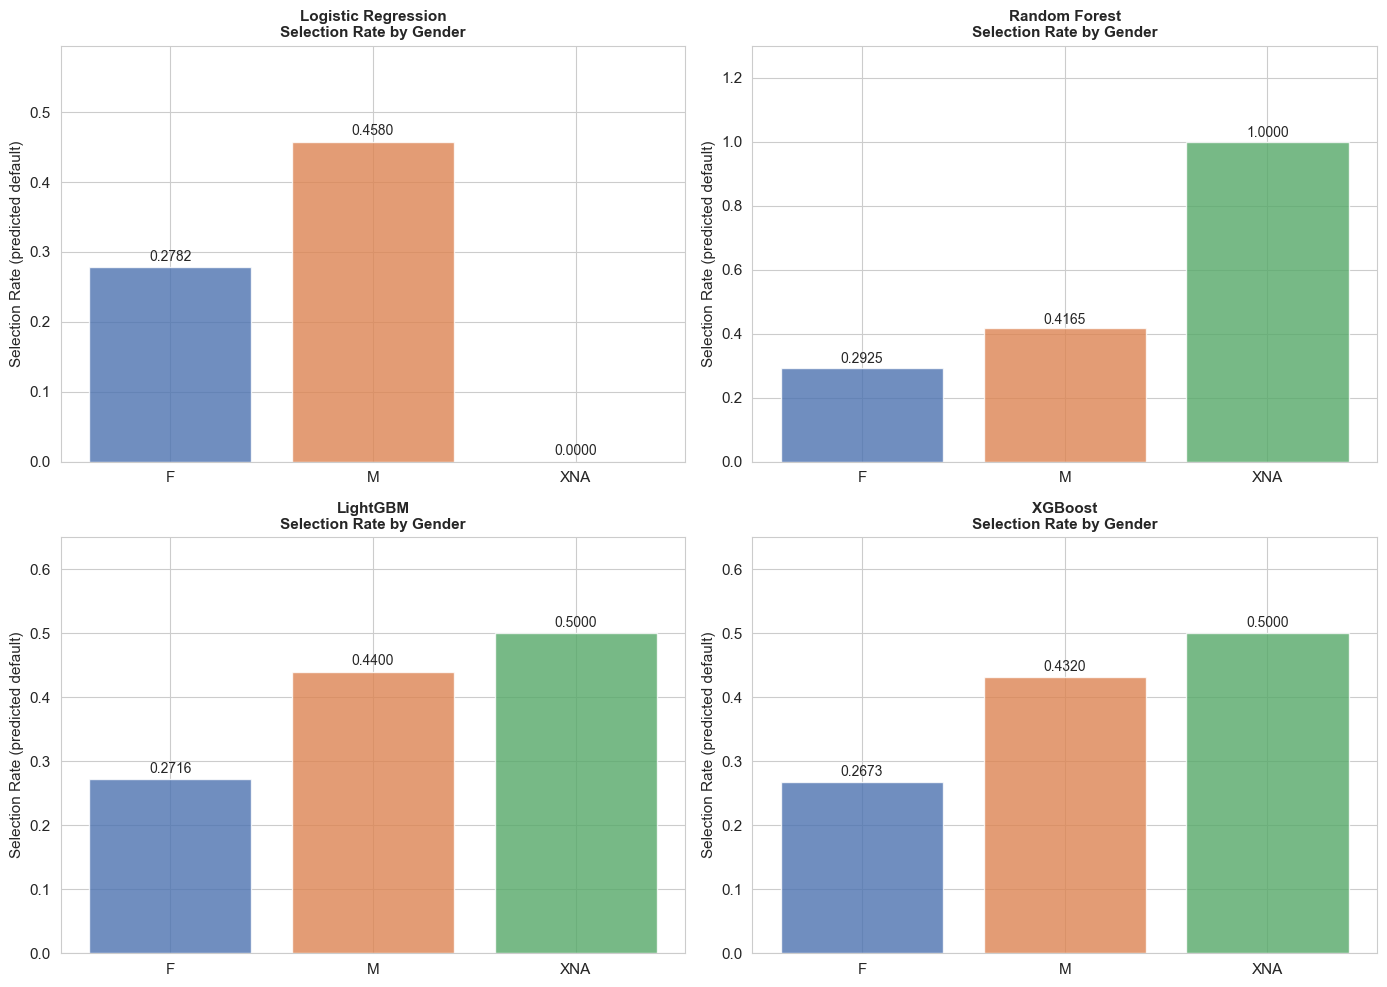

✓ Group-wise selection rate comparison generated


In [68]:
# Detailed group-wise selection rate comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (model_name, model) in enumerate(models.items()):
    y_pred = model_predictions[model_name]['y_pred']
    
    mf = MetricFrame(
        metrics={'Selection Rate': lambda y_true, y_pred: np.mean(y_pred)},
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=sensitive_feature
    )
    
    group_rates = mf.by_group['Selection Rate']
    bars = axes[idx].bar(group_rates.index, group_rates.values,
                        color=['#4C72B0', '#DD8452', '#55A868'], alpha=0.8)
    axes[idx].set_title(f'{model_name}\nSelection Rate by Gender', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Selection Rate (predicted default)')
    axes[idx].set_ylim(0, max(group_rates.values) * 1.3)
    
    for bar, val in zip(bars, group_rates.values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                      f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("✓ Group-wise selection rate comparison generated")